# Computer Vision Masterclass - Object detection with YOLO

## Object detection in images

### Downloading Darknet

In [1]:
!git clone https://github.com/AlexeyAB/darknet
%cd darknet

Cloning into 'darknet'...
remote: Enumerating objects: 15900, done.
remote: Total 15900 (delta 0), reused 0 (delta 0), pack-reused 15900 (from 1)
Receiving objects: 100% (15900/15900), 14.45 MiB | 13.88 MiB/s, done.
Resolving deltas: 100% (10703/10703), done.
/content/darknet


In [2]:
!sed -i 's/OPENCV=0/OPENCV=1/' Makefile
!sed -i 's/GPU=0/GPU=1/' Makefile
!sed -i 's/CUDNN=0/CUDNN=1/' Makefile
!sed -i 's/CUDNN_HALF=0/CUDNN_HALF=1/' Makefile

In [3]:
!sed -i 's|NVCC=.*|NVCC=nvcc --forward-unknown-to-host-compiler|' Makefile

### Compiling the library

In [4]:
!make clean
!make -j$(nproc)

rm -rf ./obj/image_opencv.o ./obj/http_stream.o ./obj/gemm.o ./obj/utils.o ./obj/dark_cuda.o ./obj/convolutional_layer.o ./obj/list.o ./obj/image.o ./obj/activations.o ./obj/im2col.o ./obj/col2im.o ./obj/blas.o ./obj/crop_layer.o ./obj/dropout_layer.o ./obj/maxpool_layer.o ./obj/softmax_layer.o ./obj/data.o ./obj/matrix.o ./obj/network.o ./obj/connected_layer.o ./obj/cost_layer.o ./obj/parser.o ./obj/option_list.o ./obj/darknet.o ./obj/detection_layer.o ./obj/captcha.o ./obj/route_layer.o ./obj/writing.o ./obj/box.o ./obj/nightmare.o ./obj/normalization_layer.o ./obj/avgpool_layer.o ./obj/coco.o ./obj/dice.o ./obj/yolo.o ./obj/detector.o ./obj/layer.o ./obj/compare.o ./obj/classifier.o ./obj/local_layer.o ./obj/swag.o ./obj/shortcut_layer.o ./obj/representation_layer.o ./obj/activation_layer.o ./obj/rnn_layer.o ./obj/gru_layer.o ./obj/rnn.o ./obj/rnn_vid.o ./obj/crnn_layer.o ./obj/demo.o ./obj/tag.o ./obj/cifar.o ./obj/go.o ./obj/batchnorm_layer.o ./obj/art.o ./obj/region_layer.o ./obj

### Downloading YOLO weights

In [5]:
!wget https://github.com/AlexeyAB/darknet/releases/download/darknet_yolo_v3_optimal/yolov4.weights

# https://storage.googleapis.com/openimages/web/index.html
# !wget https://pjreddie.com/media/files/yolov3-openimages.weights

--2025-07-20 10:55:42--  https://github.com/AlexeyAB/darknet/releases/download/darknet_yolo_v3_optimal/yolov4.weights
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/75388965/ba4b6380-889c-11ea-9751-f994f5961796?sp=r&sv=2018-11-09&sr=b&spr=https&se=2025-07-20T11%3A31%3A54Z&rscd=attachment%3B+filename%3Dyolov4.weights&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=2025-07-20T10%3A31%3A27Z&ske=2025-07-20T11%3A31%3A54Z&sks=b&skv=2018-11-09&sig=vD76qIXqUNj8hdPkLyC%2BFVpqXPM2S%2F1t4Y%2BEVDLrNwI%3D&jwt=eyJhbGciOiJIUzI1NiIsInR5cCI6IkpXVCJ9.eyJpc3MiOiJnaXRodWIuY29tIiwiYXVkIjoicmVsZWFzZS1hc3NldHMuZ2l0aHVidXNlcmNvbnRlbnQuY29tIiwia2V5Ijoia2V5MSIsImV4cCI6MTc1MzAwOTI0MiwibmJmIjoxNzUzMDA4OTQyLCJwYXRoIjoicmVsZWFzZWFzc2V0c

### Testing the object detector

In [6]:
ls

3rdparty/               data/                   obj/
backup/                 docker-compose.yml      package.xml
build/                  Dockerfile.cpu          README.md
build.ps1*              Dockerfile.gpu          results/
cfg/                    image_yolov3.sh*        scripts/
cmake/                  image_yolov4.sh*        src/
CMakeLists.txt          include/                vcpkg.json
darknet*                json_mjpeg_streams.sh*  video_yolov3.sh*
DarknetConfig.cmake.in  LICENSE                 video_yolov4.sh*
darknet_images.py       Makefile                yolov4.weights
darknet.py              net_cam_v3.sh*
darknet_video.py        net_cam_v4.sh*


In [7]:
!./darknet detect cfg/yolov4.cfg yolov4.weights data/person.jpg

 CUDA-version: 12050 (12040)
, cuDNN: 9.2.1, CUDNN_HALF=1, GPU count: 1  
 CUDNN_HALF=1 
 OpenCV version: 4.5.4
 0 : compute_capability = 750, cudnn_half = 1, GPU: Tesla T4 
net.optimized_memory = 0 
mini_batch = 1, batch = 8, time_steps = 1, train = 0 
   layer   filters  size/strd(dil)      input                output
   0 Create CUDA-stream - 0 
 Create cudnn-handle 0 
conv     32       3 x 3/ 1    608 x 608 x   3 ->  608 x 608 x  32 0.639 BF
   1 conv     64       3 x 3/ 2    608 x 608 x  32 ->  304 x 304 x  64 3.407 BF
   2 conv     64       1 x 1/ 1    304 x 304 x  64 ->  304 x 304 x  64 0.757 BF
   3 route  1 		                           ->  304 x 304 x  64 
   4 conv     64       1 x 1/ 1    304 x 304 x  64 ->  304 x 304 x  64 0.757 BF
   5 conv     32       1 x 1/ 1    304 x 304 x  64 ->  304 x 304 x  32 0.379 BF
   6 conv     64       3 x 3/ 1    304 x 304 x  32 ->  304 x 304 x  64 3.407 BF
   7 Shortcut Layer: 4,  wt = 0, wn = 0, outputs: 304 x 304 x  64 0.006 BF
   8 conv  

In [8]:
import cv2
import matplotlib.pyplot as plt

In [9]:
def show_detection(path):
    image = cv2.imread(path)
    fig = plt.gcf()
    fig.set_size_inches(18,10)
    plt.axis('off')
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))

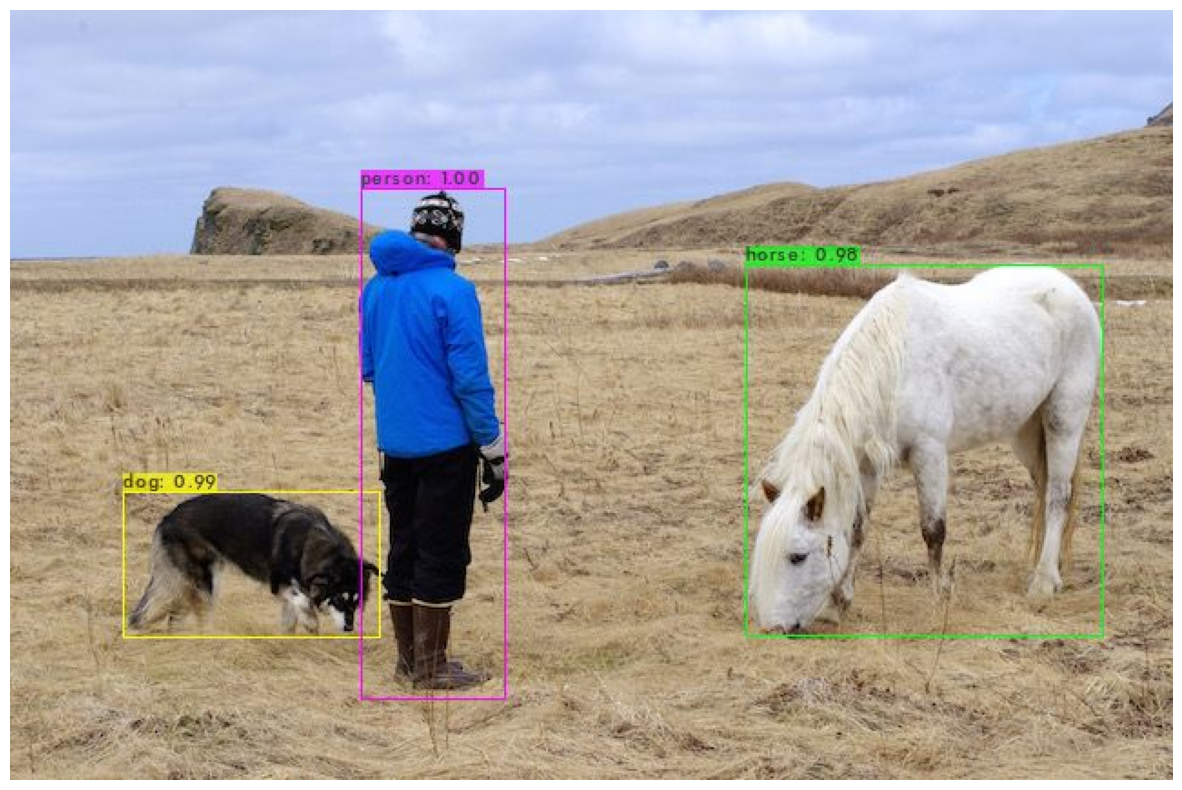

In [10]:
show_detection('predictions.jpg')

### Darknet and GPU

In [11]:
import tensorflow as tf
tf.test.gpu_device_name()

'/device:GPU:0'

In [12]:
ls

3rdparty/               data/                   obj/
backup/                 docker-compose.yml      package.xml
build/                  Dockerfile.cpu          predictions.jpg
build.ps1*              Dockerfile.gpu          README.md
cfg/                    image_yolov3.sh*        results/
cmake/                  image_yolov4.sh*        scripts/
CMakeLists.txt          include/                src/
darknet*                json_mjpeg_streams.sh*  vcpkg.json
DarknetConfig.cmake.in  LICENSE                 video_yolov3.sh*
darknet_images.py       Makefile                video_yolov4.sh*
darknet.py              net_cam_v3.sh*          yolov4.weights
darknet_video.py        net_cam_v4.sh*


In [13]:
!sed -i 's/OPENCV=0/OPENCV=1/' Makefile
!sed -i 's/GPU=0/GPU=1/' Makefile
!sed -i 's/CUDNN=0/CUDNN=1/' Makefile
!sed -i 's/CUDNN_HALF=0/CUDNN_HALF=1/' Makefile

In [14]:
!sed -i 's|NVCC=.*|NVCC=nvcc --forward-unknown-to-host-compiler|' Makefile

In [15]:
!make clean
!make -j$(nproc)

rm -rf ./obj/image_opencv.o ./obj/http_stream.o ./obj/gemm.o ./obj/utils.o ./obj/dark_cuda.o ./obj/convolutional_layer.o ./obj/list.o ./obj/image.o ./obj/activations.o ./obj/im2col.o ./obj/col2im.o ./obj/blas.o ./obj/crop_layer.o ./obj/dropout_layer.o ./obj/maxpool_layer.o ./obj/softmax_layer.o ./obj/data.o ./obj/matrix.o ./obj/network.o ./obj/connected_layer.o ./obj/cost_layer.o ./obj/parser.o ./obj/option_list.o ./obj/darknet.o ./obj/detection_layer.o ./obj/captcha.o ./obj/route_layer.o ./obj/writing.o ./obj/box.o ./obj/nightmare.o ./obj/normalization_layer.o ./obj/avgpool_layer.o ./obj/coco.o ./obj/dice.o ./obj/yolo.o ./obj/detector.o ./obj/layer.o ./obj/compare.o ./obj/classifier.o ./obj/local_layer.o ./obj/swag.o ./obj/shortcut_layer.o ./obj/representation_layer.o ./obj/activation_layer.o ./obj/rnn_layer.o ./obj/gru_layer.o ./obj/rnn.o ./obj/rnn_vid.o ./obj/crnn_layer.o ./obj/demo.o ./obj/tag.o ./obj/cifar.o ./obj/go.o ./obj/batchnorm_layer.o ./obj/art.o ./obj/region_layer.o ./obj

In [16]:
!./darknet detect cfg/yolov4.cfg yolov4.weights data/giraffe.jpg

 CUDA-version: 12050 (12040)
, cuDNN: 9.2.1, CUDNN_HALF=1, GPU count: 1  
 CUDNN_HALF=1 
 OpenCV version: 4.5.4
 0 : compute_capability = 750, cudnn_half = 1, GPU: Tesla T4 
net.optimized_memory = 0 
mini_batch = 1, batch = 8, time_steps = 1, train = 0 
   layer   filters  size/strd(dil)      input                output
   0 Create CUDA-stream - 0 
 Create cudnn-handle 0 
conv     32       3 x 3/ 1    608 x 608 x   3 ->  608 x 608 x  32 0.639 BF
   1 conv     64       3 x 3/ 2    608 x 608 x  32 ->  304 x 304 x  64 3.407 BF
   2 conv     64       1 x 1/ 1    304 x 304 x  64 ->  304 x 304 x  64 0.757 BF
   3 route  1 		                           ->  304 x 304 x  64 
   4 conv     64       1 x 1/ 1    304 x 304 x  64 ->  304 x 304 x  64 0.757 BF
   5 conv     32       1 x 1/ 1    304 x 304 x  64 ->  304 x 304 x  32 0.379 BF
   6 conv     64       3 x 3/ 1    304 x 304 x  32 ->  304 x 304 x  64 3.407 BF
   7 Shortcut Layer: 4,  wt = 0, wn = 0, outputs: 304 x 304 x  64 0.006 BF
   8 conv  

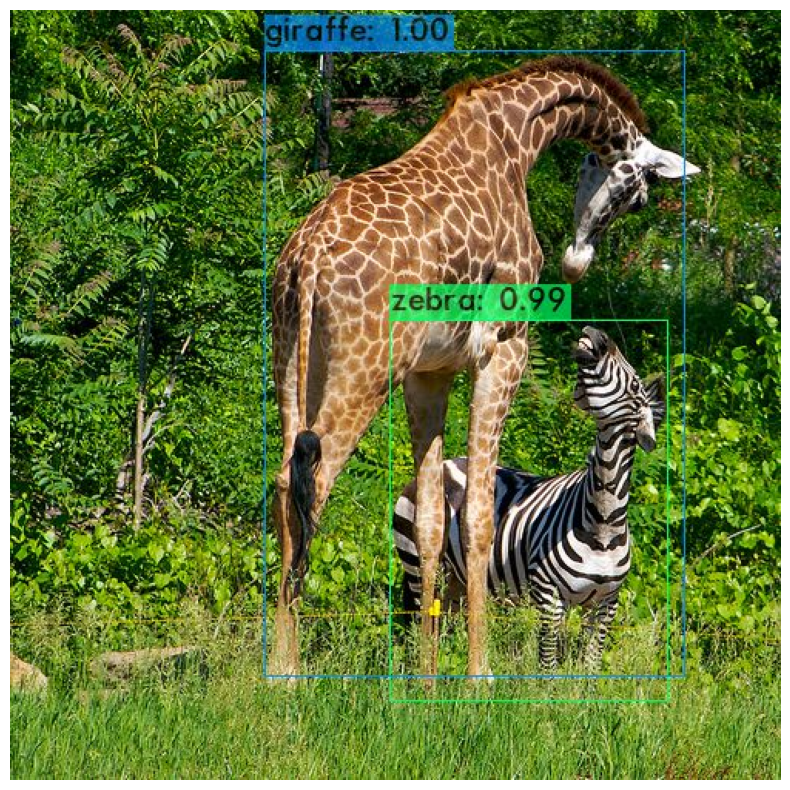

In [17]:
# Coco dataset: https://cocodataset.org/#home
show_detection('predictions.jpg')

### Threshold

In [18]:
!./darknet detect cfg/yolov4.cfg yolov4.weights data/horses.jpg

 CUDA-version: 12050 (12040)
, cuDNN: 9.2.1, CUDNN_HALF=1, GPU count: 1  
 CUDNN_HALF=1 
 OpenCV version: 4.5.4
 0 : compute_capability = 750, cudnn_half = 1, GPU: Tesla T4 
net.optimized_memory = 0 
mini_batch = 1, batch = 8, time_steps = 1, train = 0 
   layer   filters  size/strd(dil)      input                output
   0 Create CUDA-stream - 0 
 Create cudnn-handle 0 
conv     32       3 x 3/ 1    608 x 608 x   3 ->  608 x 608 x  32 0.639 BF
   1 conv     64       3 x 3/ 2    608 x 608 x  32 ->  304 x 304 x  64 3.407 BF
   2 conv     64       1 x 1/ 1    304 x 304 x  64 ->  304 x 304 x  64 0.757 BF
   3 route  1 		                           ->  304 x 304 x  64 
   4 conv     64       1 x 1/ 1    304 x 304 x  64 ->  304 x 304 x  64 0.757 BF
   5 conv     32       1 x 1/ 1    304 x 304 x  64 ->  304 x 304 x  32 0.379 BF
   6 conv     64       3 x 3/ 1    304 x 304 x  32 ->  304 x 304 x  64 3.407 BF
   7 Shortcut Layer: 4,  wt = 0, wn = 0, outputs: 304 x 304 x  64 0.006 BF
   8 conv  

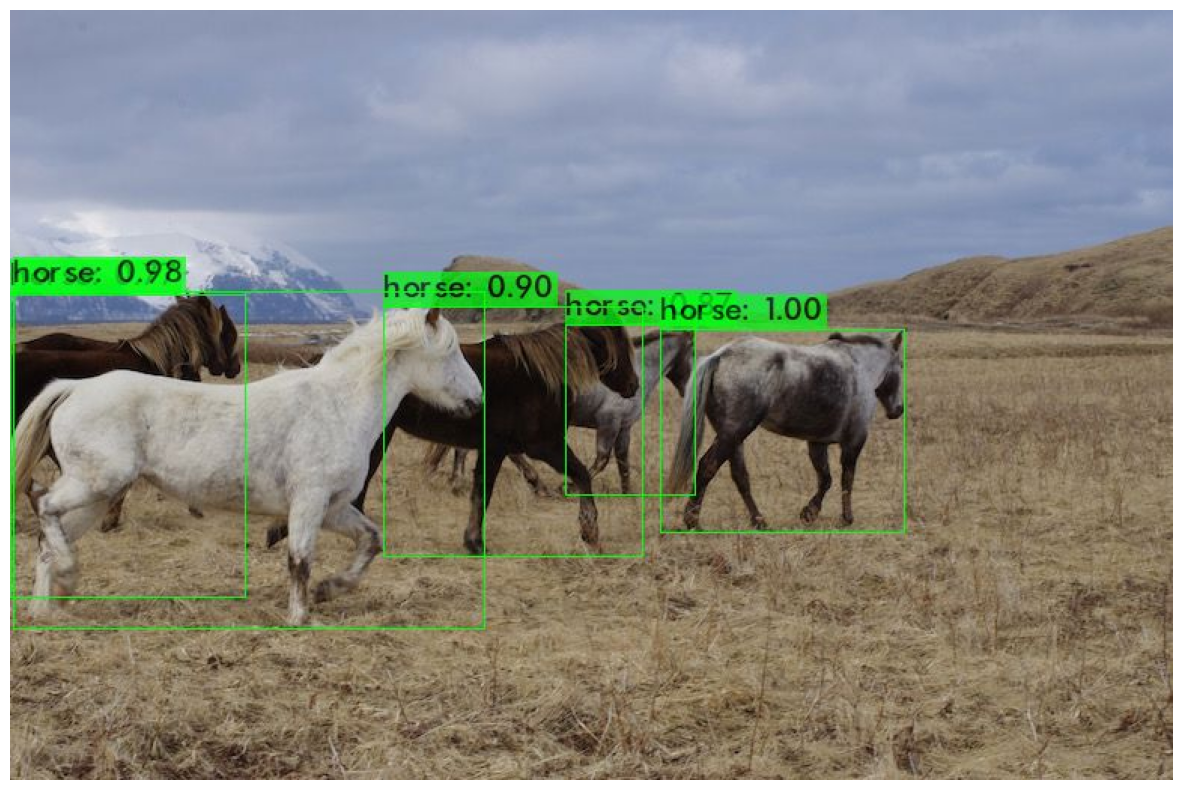

In [19]:
show_detection('predictions.jpg')

In [20]:
!./darknet detect cfg/yolov4.cfg yolov4.weights data/horses.jpg -thresh 0.9

 CUDA-version: 12050 (12040)
, cuDNN: 9.2.1, CUDNN_HALF=1, GPU count: 1  
 CUDNN_HALF=1 
 OpenCV version: 4.5.4
 0 : compute_capability = 750, cudnn_half = 1, GPU: Tesla T4 
net.optimized_memory = 0 
mini_batch = 1, batch = 8, time_steps = 1, train = 0 
   layer   filters  size/strd(dil)      input                output
   0 Create CUDA-stream - 0 
 Create cudnn-handle 0 
conv     32       3 x 3/ 1    608 x 608 x   3 ->  608 x 608 x  32 0.639 BF
   1 conv     64       3 x 3/ 2    608 x 608 x  32 ->  304 x 304 x  64 3.407 BF
   2 conv     64       1 x 1/ 1    304 x 304 x  64 ->  304 x 304 x  64 0.757 BF
   3 route  1 		                           ->  304 x 304 x  64 
   4 conv     64       1 x 1/ 1    304 x 304 x  64 ->  304 x 304 x  64 0.757 BF
   5 conv     32       1 x 1/ 1    304 x 304 x  64 ->  304 x 304 x  32 0.379 BF
   6 conv     64       3 x 3/ 1    304 x 304 x  32 ->  304 x 304 x  64 3.407 BF
   7 Shortcut Layer: 4,  wt = 0, wn = 0, outputs: 304 x 304 x  64 0.006 BF
   8 conv  

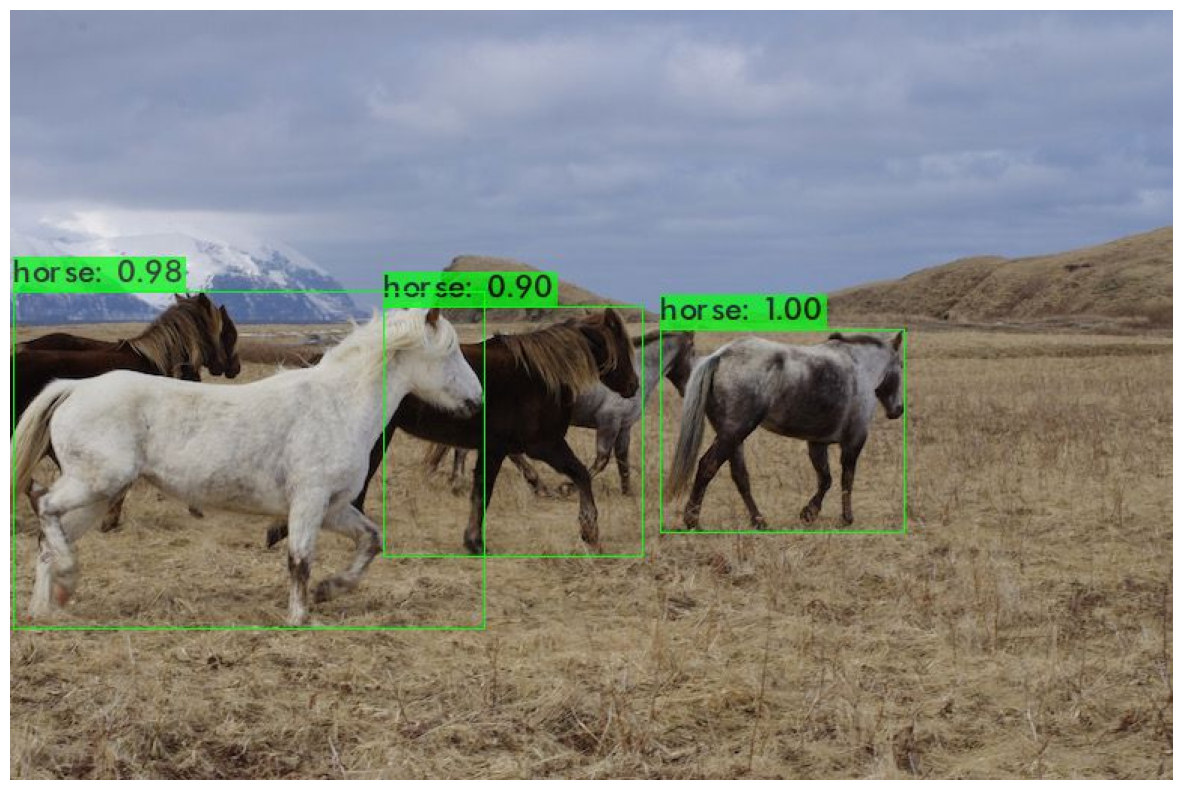

In [21]:
show_detection('predictions.jpg')

In [22]:
!./darknet detect cfg/yolov4.cfg yolov4.weights data/horses.jpg -thresh 0.98

 CUDA-version: 12050 (12040)
, cuDNN: 9.2.1, CUDNN_HALF=1, GPU count: 1  
 CUDNN_HALF=1 
 OpenCV version: 4.5.4
 0 : compute_capability = 750, cudnn_half = 1, GPU: Tesla T4 
net.optimized_memory = 0 
mini_batch = 1, batch = 8, time_steps = 1, train = 0 
   layer   filters  size/strd(dil)      input                output
   0 Create CUDA-stream - 0 
 Create cudnn-handle 0 
conv     32       3 x 3/ 1    608 x 608 x   3 ->  608 x 608 x  32 0.639 BF
   1 conv     64       3 x 3/ 2    608 x 608 x  32 ->  304 x 304 x  64 3.407 BF
   2 conv     64       1 x 1/ 1    304 x 304 x  64 ->  304 x 304 x  64 0.757 BF
   3 route  1 		                           ->  304 x 304 x  64 
   4 conv     64       1 x 1/ 1    304 x 304 x  64 ->  304 x 304 x  64 0.757 BF
   5 conv     32       1 x 1/ 1    304 x 304 x  64 ->  304 x 304 x  32 0.379 BF
   6 conv     64       3 x 3/ 1    304 x 304 x  32 ->  304 x 304 x  64 3.407 BF
   7 Shortcut Layer: 4,  wt = 0, wn = 0, outputs: 304 x 304 x  64 0.006 BF
   8 conv  

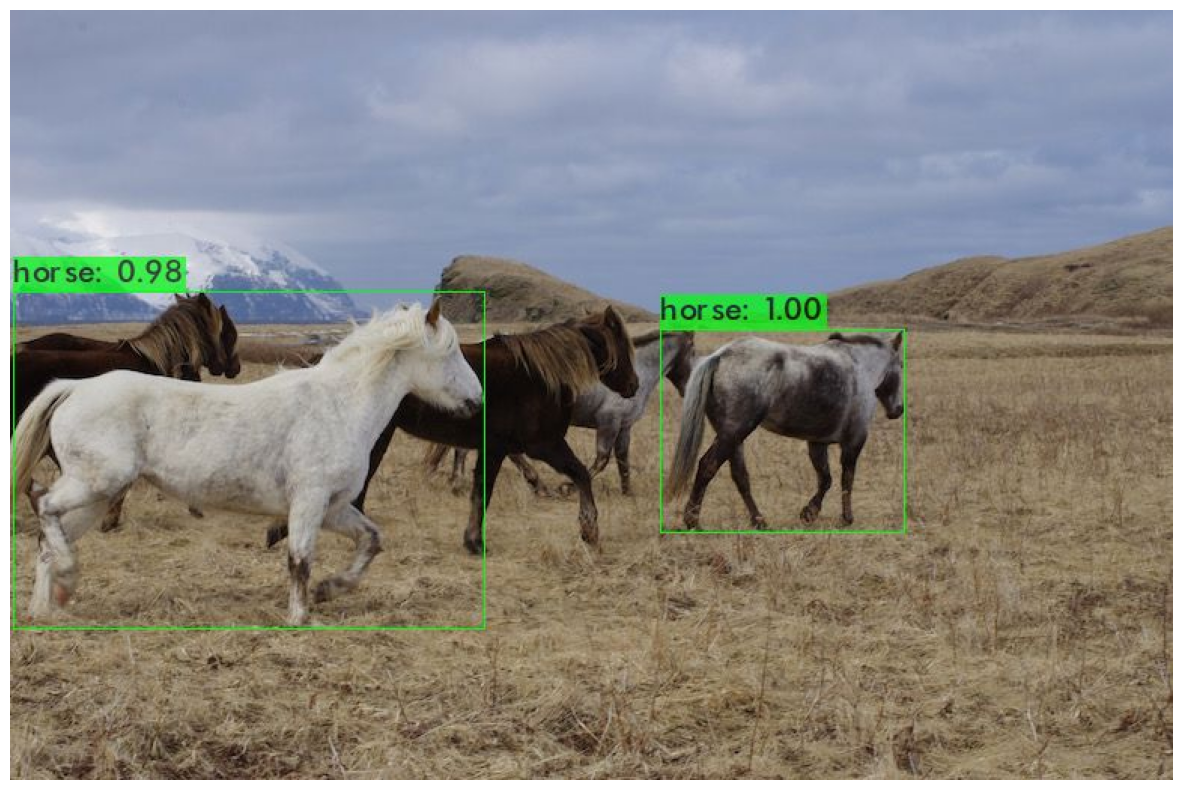

In [23]:
show_detection('predictions.jpg')

In [24]:
!./darknet detect cfg/yolov4.cfg yolov4.weights data/horses.jpg -thresh 0.00001

 CUDA-version: 12050 (12040)
, cuDNN: 9.2.1, CUDNN_HALF=1, GPU count: 1  
 CUDNN_HALF=1 
 OpenCV version: 4.5.4
 0 : compute_capability = 750, cudnn_half = 1, GPU: Tesla T4 
net.optimized_memory = 0 
mini_batch = 1, batch = 8, time_steps = 1, train = 0 
   layer   filters  size/strd(dil)      input                output
   0 Create CUDA-stream - 0 
 Create cudnn-handle 0 
conv     32       3 x 3/ 1    608 x 608 x   3 ->  608 x 608 x  32 0.639 BF
   1 conv     64       3 x 3/ 2    608 x 608 x  32 ->  304 x 304 x  64 3.407 BF
   2 conv     64       1 x 1/ 1    304 x 304 x  64 ->  304 x 304 x  64 0.757 BF
   3 route  1 		                           ->  304 x 304 x  64 
   4 conv     64       1 x 1/ 1    304 x 304 x  64 ->  304 x 304 x  64 0.757 BF
   5 conv     32       1 x 1/ 1    304 x 304 x  64 ->  304 x 304 x  32 0.379 BF
   6 conv     64       3 x 3/ 1    304 x 304 x  32 ->  304 x 304 x  64 3.407 BF
   7 Shortcut Layer: 4,  wt = 0, wn = 0, outputs: 304 x 304 x  64 0.006 BF
   8 conv  

In [25]:
show_detection('predictions.jpg')

Output hidden; open in https://colab.research.google.com to view.

### ext_output

In [26]:
!./darknet detect cfg/yolov4.cfg yolov4.weights data/horses.jpg -ext_output

 CUDA-version: 12050 (12040)
, cuDNN: 9.2.1, CUDNN_HALF=1, GPU count: 1  
 CUDNN_HALF=1 
 OpenCV version: 4.5.4
 0 : compute_capability = 750, cudnn_half = 1, GPU: Tesla T4 
net.optimized_memory = 0 
mini_batch = 1, batch = 8, time_steps = 1, train = 0 
   layer   filters  size/strd(dil)      input                output
   0 Create CUDA-stream - 0 
 Create cudnn-handle 0 
conv     32       3 x 3/ 1    608 x 608 x   3 ->  608 x 608 x  32 0.639 BF
   1 conv     64       3 x 3/ 2    608 x 608 x  32 ->  304 x 304 x  64 3.407 BF
   2 conv     64       1 x 1/ 1    304 x 304 x  64 ->  304 x 304 x  64 0.757 BF
   3 route  1 		                           ->  304 x 304 x  64 
   4 conv     64       1 x 1/ 1    304 x 304 x  64 ->  304 x 304 x  64 0.757 BF
   5 conv     32       1 x 1/ 1    304 x 304 x  64 ->  304 x 304 x  32 0.379 BF
   6 conv     64       3 x 3/ 1    304 x 304 x  32 ->  304 x 304 x  64 3.407 BF
   7 Shortcut Layer: 4,  wt = 0, wn = 0, outputs: 304 x 304 x  64 0.006 BF
   8 conv  

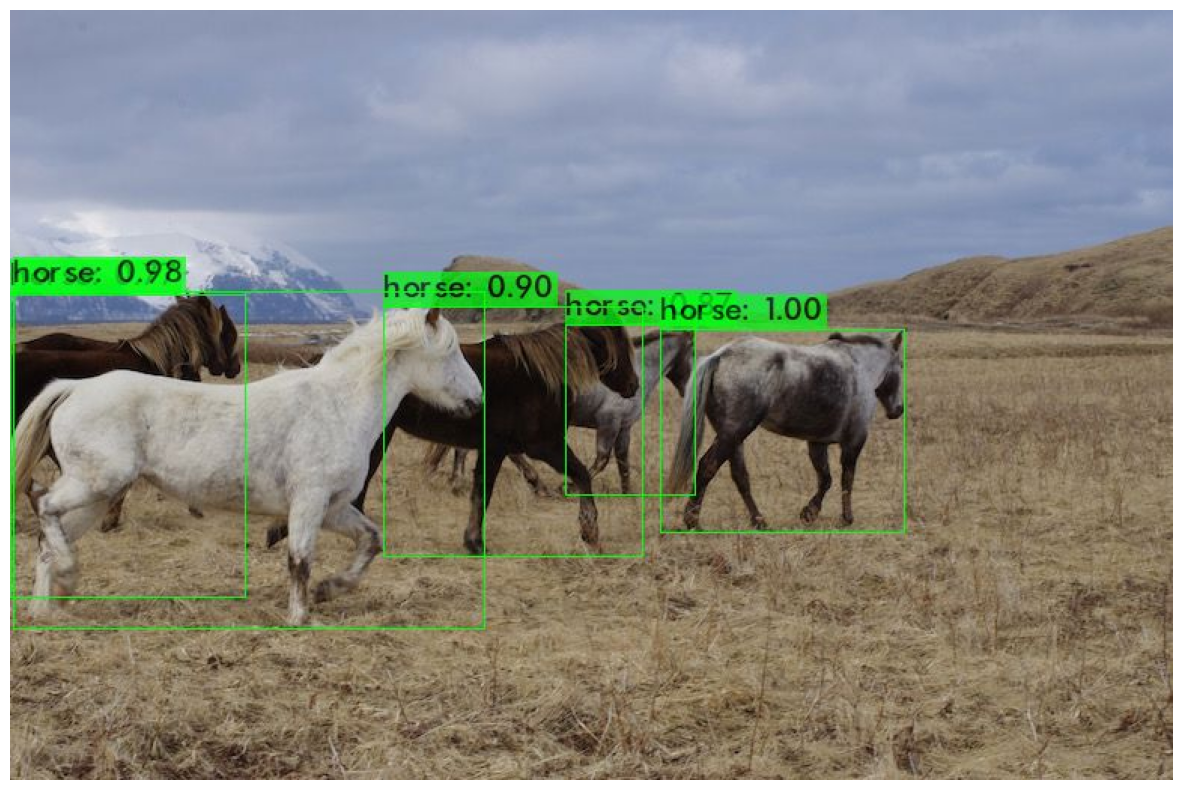

In [27]:
show_detection('predictions.jpg')

## Object detection in videos

In [28]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [29]:
ls

3rdparty/               data/                   obj/
backup/                 docker-compose.yml      package.xml
build/                  Dockerfile.cpu          predictions.jpg
build.ps1*              Dockerfile.gpu          README.md
cfg/                    image_yolov3.sh*        results/
cmake/                  image_yolov4.sh*        scripts/
CMakeLists.txt          include/                src/
darknet*                json_mjpeg_streams.sh*  vcpkg.json
DarknetConfig.cmake.in  LICENSE                 video_yolov3.sh*
darknet_images.py       Makefile                video_yolov4.sh*
darknet.py              net_cam_v3.sh*          yolov4.weights
darknet_video.py        net_cam_v4.sh*


In [30]:
!./darknet detector demo cfg/coco.data cfg/yolov4.cfg yolov4.weights -dont_show /content/drive/MyDrive/Computer-Vision/Videos/video_street.mp4 -i 0 -out_filename /content/drive/MyDrive/Computer-Vision/Videos/video_street_result.avi

Görüntülenen çıkış son 5000 satıra kısaltıldı.
person: 85% 
person: 78% 
person: 48% 
person: 43% 
person: 34% 

FPS:12.4 	 AVG_FPS:11.7

 cvWriteFrame 
Objects:

handbag: 52% 
traffic light: 44% 
car: 99% 
car: 97% 
person: 100% 
person: 99% 
person: 98% 
person: 96% 
person: 95% 
person: 95% 
person: 93% 
person: 81% 
person: 77% 
person: 51% 
person: 50% 
person: 42% 

FPS:12.4 	 AVG_FPS:11.7

 cvWriteFrame 
Objects:

handbag: 32% 
traffic light: 42% 
car: 99% 
car: 97% 
person: 100% 
person: 99% 
person: 98% 
person: 98% 
person: 95% 
person: 95% 
person: 95% 
person: 74% 
person: 69% 
person: 58% 
person: 48% 
person: 47% 
person: 47% 
person: 42% 
person: 35% 

FPS:12.3 	 AVG_FPS:11.7

 cvWriteFrame 
Objects:

handbag: 27% 
traffic light: 45% 
car: 98% 
car: 97% 
car: 30% 
person: 100% 
person: 98% 
person: 98% 
person: 98% 
person: 98% 
person: 96% 
person: 95% 
person: 95% 
person: 77% 
person: 75% 
person: 59% 
person: 57% 
person: 44% 
person: 42% 

FPS:12.0 	 AVG_FPS:11.7

 

In [31]:
!./darknet detector demo cfg/coco.data cfg/yolov4.cfg yolov4.weights -dont_show /content/drive/MyDrive/Computer-Vision/Videos/video_people.mp4 -i 0 -out_filename /content/drive/MyDrive/Computer-Vision/Videos/video_people_result.avi

Görüntülenen çıkış son 5000 satıra kısaltıldı.
person: 95% 
person: 75% 
person: 64% 
person: 55% 
person: 45% 

FPS:30.2 	 AVG_FPS:0.0

 cvWriteFrame 
Objects:

book: 41% 
laptop: 98% 
handbag: 45% 
backpack: 78% 
person: 95% 
person: 75% 
person: 62% 
person: 51% 
person: 46% 
person: 29% 

FPS:29.3 	 AVG_FPS:0.0

 cvWriteFrame 
Objects:

book: 44% 
laptop: 98% 
handbag: 28% 
handbag: 25% 
backpack: 85% 
person: 94% 
person: 67% 
person: 63% 
person: 62% 
person: 49% 
person: 39% 

FPS:29.3 	 AVG_FPS:0.0

 cvWriteFrame 
Objects:

book: 39% 
laptop: 98% 
handbag: 25% 
backpack: 88% 
person: 94% 
person: 68% 
person: 62% 
person: 61% 
person: 49% 
person: 34% 

FPS:28.8 	 AVG_FPS:0.0

 cvWriteFrame 
Objects:

book: 30% 
laptop: 98% 
backpack: 85% 
person: 94% 
person: 73% 
person: 72% 
person: 52% 
person: 44% 
person: 35% 

FPS:28.8 	 AVG_FPS:0.0

 cvWriteFrame 
Objects:

book: 35% 
laptop: 97% 
backpack: 83% 
person: 91% 
person: 79% 
person: 66% 
person: 43% 
person: 40% 
person: 39